### Core functions

In [1]:
import os
import warnings
import numpy as np
from tqdm import tqdm
import matplotlib.pyplot as plt
from matplotlib.gridspec import GridSpec

from sklearn import datasets
from sklearn.preprocessing import StandardScaler
from sklearn.ensemble import RandomForestClassifier
from sklearn.neighbors import KNeighborsClassifier, RadiusNeighborsClassifier
from sklearn.pipeline import make_pipeline
from sklearn.preprocessing import StandardScaler
from sklearn.neural_network import MLPClassifier
from sklearn.exceptions import ConvergenceWarning

import src.auxiliar as aux
import src.entropy_estimator as entropy_estimator

SMALL_SIZE = 10
MEDIUM_SIZE = 14
BIGGER_SIZE = 18

plt.rc('font', size=SMALL_SIZE)          # controls default text sizes
plt.rc('axes', titlesize=BIGGER_SIZE)     # fontsize of the axes title
plt.rc('axes', labelsize=MEDIUM_SIZE)    # fontsize of the x and y labels
plt.rc('xtick', labelsize=SMALL_SIZE)    # fontsize of the tick labels
plt.rc('ytick', labelsize=SMALL_SIZE)    # fontsize of the tick labels
plt.rc('legend', fontsize=SMALL_SIZE)    # legend fontsize
plt.rc('figure', titlesize=BIGGER_SIZE)  # fontsize of the figure title

reds = aux.CustomCmap([60/255,60/255,60/255], [196/255,60/255,60/255])
greens = aux.CustomCmap([0.1, 0.3, 0.1], [0.1, 0.8, 0.1])
blues = aux.CustomCmap([60/255,60/255,60/255], [45/255,159/255,255/255])
teals = aux.CustomCmap([60/255,60/255,60/255], [0/255,200/255,130/255])

class_colors = ['#2D9FFF', '#FF5154', '#E5D352', '#00C882']
model_colors = ['#2D9FFF', '#FF5154', '#E5D352', '#00C882']


# We choose the size big enough to see the scalability of the algorithms, but not too big to avoid too long running times
n_samples = 500

In [2]:
def train_models_with_noise(model_fn, exp_name, train_gen, test_gen, noise_space, data_path, samples=10):
	model_errors = []
	for noise in tqdm(noise_space):
		x_train, y_train = train_gen(noise)
		x_test, y_test = test_gen(noise)
		errors = []
		for _ in range(samples):
			clf = model_fn()
			clf = make_pipeline(StandardScaler(), clf)
			clf.fit(x_train, y_train)
			score = clf.score(x_test, y_test)
			errors.append(score)
		model_errors.append(errors)
	os.makedirs(data_path, exist_ok=True)
	np.save(os.path.join(data_path, f'{exp_name}.npy'), model_errors)

### Dataset 1: Circles

In [8]:
gs_pos = [[0,3], [0,4], [0,5], [1,3], [1,4], [1,5]]
rng_states = [42] * 3 + [43] * 3
noise_values = [0.03, 0.25, 1.0] * 2
data_path = './data/simple_circles'
os.makedirs(data_path, exist_ok=True)
d_value = 0.05
factor = 0.5
noise_points = 25
noise_space = np.linspace(0, 1, noise_points)
dataset_fn = lambda samples, rng, noise : datasets.make_circles(n_samples=samples, factor=factor, noise=noise, random_state=rng)

train_classificabilities, test_classificabilities = [], []
for noise in noise_space:
	with np.errstate(divide='ignore', invalid='ignore'):
		# Train
		x_data, y_data = dataset_fn(n_samples, 42, noise)
		c = entropy_estimator.classificability_estimator(x_data, y_data, k_neighbors=16)
		train_classificabilities.append(c)
		# Test
		x_data, y_data = dataset_fn(n_samples, 43, noise)
		c = entropy_estimator.classificability_estimator(x_data, y_data, k_neighbors=16)
		test_classificabilities.append(c)
np.save(os.path.join(data_path, f'train_classificabilities.npy'), train_classificabilities)
np.save(os.path.join(data_path, f'test_classificabilities.npy'), test_classificabilities)

d_value = 0.015
high_res_limit = []
for noise in tqdm(noise_space):
	with np.errstate(divide='ignore', invalid='ignore'):
		# Train
		x_data, y_data = dataset_fn(25000, 42, noise)
		c = entropy_estimator.classificability_estimator(x_data, y_data, k_neighbors=32)
		high_res_limit.append(c)
np.save(os.path.join(data_path, f'high_res_limit.npy'), high_res_limit)

100%|██████████| 25/25 [00:05<00:00,  4.82it/s]


In [ ]:
train_gen = lambda noise : dataset_fn(n_samples, 42, noise)
test_gen = lambda noise : dataset_fn(n_samples, 43, noise)

exp_names = ['rfc', 'knc', 'rnc', 'mlp']
exp_long_name = ['Random Forest', 'K Neighbors', 'Radius Neighbors', 'Multilayer Perceptron']
models_fn = [lambda : RandomForestClassifier(), 
			 lambda : KNeighborsClassifier(),
			 lambda : RadiusNeighborsClassifier(),
			 lambda : MLPClassifier(hidden_layer_sizes=[128,64,32], batch_size=32)]
exp_samples = [25,1,1,25]

for exp, model, s in zip(exp_names, models_fn, exp_samples):
	with warnings.catch_warnings():
		warnings.filterwarnings("ignore", category=ConvergenceWarning)
		train_models_with_noise(model, exp, train_gen, test_gen, noise_space, data_path, samples=s)

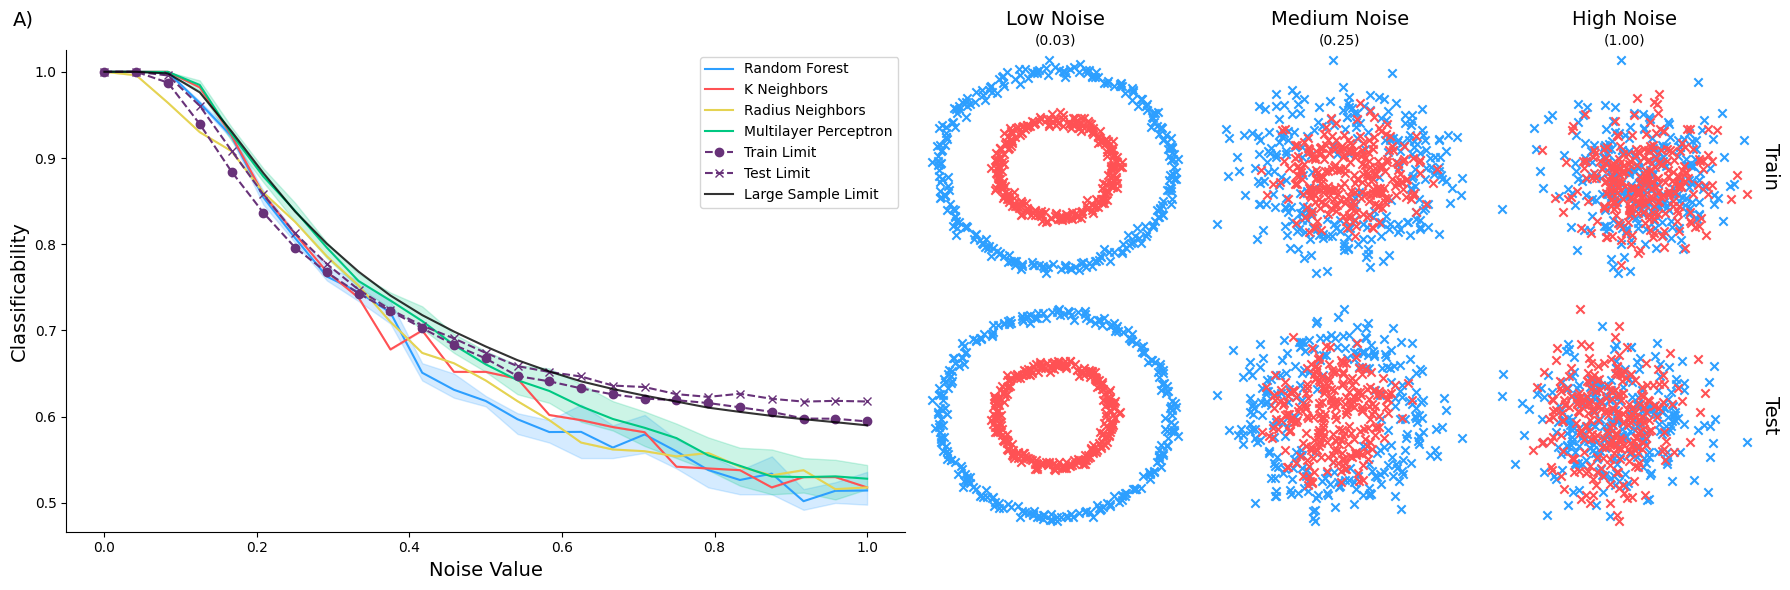

In [9]:
fig = plt.figure(figsize=(18, 6))
gs = GridSpec(2, 6, figure=fig)

ax = fig.add_subplot(gs[:, :3])

exp_names = ['rfc', 'knc', 'rnc', 'mlp']
exp_long_name = ['Random Forest', 'K Neighbors', 'Radius Neighbors', 'Multilayer Perceptron']
gs_pos = [[0,3], [0,4], [0,5], [1,3], [1,4], [1,5]]
rng_states = [42] * 3 + [43] * 3
noise_values = [0.03, 0.25, 1.0] * 2
data_path = './data/simple_circles'
noise_space = np.linspace(0, 1, noise_points)
dataset_fn = lambda samples, rng, noise : datasets.make_circles(n_samples=samples, factor=factor, noise=noise, random_state=rng)

for i, (exp, exp_long) in enumerate(zip(exp_names, exp_long_name)):
	model_errors = list(np.load(os.path.join(data_path, f'{exp}.npy')))
	ax.plot(noise_space, np.mean(model_errors, axis=1), label=exp_long, color=model_colors[i])
	ax.fill_between(noise_space, np.min(model_errors, axis=1), np.max(model_errors, axis=1), alpha=0.2, color=model_colors[i])


train_classificabilities = np.load(os.path.join(data_path, f'train_classificabilities.npy'))
test_classificabilities = np.load(os.path.join(data_path, f'test_classificabilities.npy'))
high_res_limit = np.load(os.path.join(data_path, f'high_res_limit.npy'))
ax.plot(noise_space, train_classificabilities, 'o--', alpha=1, label='Train Limit', color='#683279')
ax.plot(noise_space, test_classificabilities, 'x--', alpha=1, label='Test Limit', color='#683279')
ax.plot(noise_space, high_res_limit, 'k', alpha=0.8, label='Large Sample Limit')

ax.legend()


#ax.scatter(x_data[y_data == 0][:,0], x_data[y_data == 0][:,1])
ax.spines['top'].set_visible(False)
ax.spines['right'].set_visible(False)
ax.set_xlabel('Noise Value')
ax.set_ylabel('Classificability')

for p, rng, noise in zip(gs_pos, rng_states, noise_values):
	ax = fig.add_subplot(gs[p[0], p[1]])

	x_data, y_data = dataset_fn(n_samples, rng, noise)
	for i in range(len(np.unique(y_data))):
		ax.scatter(x_data[y_data == i][:,0], x_data[y_data == i][:,1], marker='x', color=class_colors[i])

	ax.spines['top'].set_visible(False)
	ax.spines['right'].set_visible(False)
	ax.spines['bottom'].set_visible(False)
	ax.spines['left'].set_visible(False)
	ax.set_xticks([])
	ax.set_yticks([])

fig.axes[1].set_title(f'Low Noise', fontsize=MEDIUM_SIZE)
aux_ax = fig.axes[1].twiny()
aux_ax.set_xlabel(f'({noise_values[0]:.2f})', fontsize=SMALL_SIZE)
aux_ax.spines['top'].set_visible(False)
aux_ax.spines['right'].set_visible(False)
aux_ax.spines['bottom'].set_visible(False)
aux_ax.spines['left'].set_visible(False)
aux_ax.set_xticks([])
aux_ax.set_xticklabels([])

fig.axes[2].set_title('Medium Noise', fontsize=MEDIUM_SIZE)
aux_ax = fig.axes[2].twiny()
aux_ax.set_xlabel(f'({noise_values[1]:.2f})', fontsize=SMALL_SIZE)
aux_ax.spines['top'].set_visible(False)
aux_ax.spines['right'].set_visible(False)
aux_ax.spines['bottom'].set_visible(False)
aux_ax.spines['left'].set_visible(False)
aux_ax.set_xticks([])
aux_ax.set_xticklabels([])

fig.axes[3].set_title('High Noise', fontsize=MEDIUM_SIZE)
aux_ax = fig.axes[3].twiny()
aux_ax.set_xlabel(f'({noise_values[2]:.2f})', fontsize=SMALL_SIZE)
aux_ax.spines['top'].set_visible(False)
aux_ax.spines['right'].set_visible(False)
aux_ax.spines['bottom'].set_visible(False)
aux_ax.spines['left'].set_visible(False)
aux_ax.set_xticks([])
aux_ax.set_xticklabels([])

fig.axes[3].set_ylabel('Train', rotation=270, labelpad=15)
fig.axes[3].yaxis.set_label_position("right")

fig.axes[6].set_ylabel('Test', rotation=270, labelpad=15)
fig.axes[6].yaxis.set_label_position("right")

fig.text(0.01,0.95, 'A)', fontsize=MEDIUM_SIZE)

plt.tight_layout()
plt.savefig('./images/dataset_circles.png', dpi=300)
plt.show()

### Dataset 2: Two moons

In [10]:
gs_pos = [[0,3], [0,4], [0,5], [1,3], [1,4], [1,5]]
rng_states = [42] * 3 + [43] * 3
noise_values = [0.03, 0.25, 1.0] * 2
data_path = './data/two_moons'
os.makedirs(data_path, exist_ok=True)
d_value = 0.05
factor = 0.5
noise_points = 25
noise_space = np.linspace(0, 1, noise_points)
dataset_fn = lambda samples, rng, noise : datasets.make_moons(n_samples=samples, noise=noise, random_state=rng)

train_classificabilities, test_classificabilities = [], []
for noise in noise_space:
	with np.errstate(divide='ignore', invalid='ignore'):
		# Train
		x_data, y_data = dataset_fn(n_samples, 42, noise)
		c = entropy_estimator.classificability_estimator(x_data, y_data, k_neighbors=16)
		train_classificabilities.append(c)
		# Test
		x_data, y_data = dataset_fn(n_samples, 43, noise)
		c = entropy_estimator.classificability_estimator(x_data, y_data, k_neighbors=16)
		test_classificabilities.append(c)
np.save(os.path.join(data_path, f'train_classificabilities.npy'), train_classificabilities)
np.save(os.path.join(data_path, f'test_classificabilities.npy'), test_classificabilities)

d_value = 0.015
high_res_limit = []
for noise in tqdm(noise_space):
	with np.errstate(divide='ignore', invalid='ignore'):
		# Train
		x_data, y_data = dataset_fn(25000, 42, noise)
		c = entropy_estimator.classificability_estimator(x_data, y_data, k_neighbors=32)
		high_res_limit.append(c)
np.save(os.path.join(data_path, f'high_res_limit.npy'), high_res_limit)

100%|██████████| 25/25 [00:05<00:00,  4.93it/s]


In [ ]:
train_gen = lambda noise : dataset_fn(n_samples, 42, noise)
test_gen = lambda noise : dataset_fn(n_samples, 43, noise)

exp_names = ['rfc', 'knc', 'rnc', 'mlp']
exp_long_name = ['Random Forest', 'K Neighbors', 'Radius Neighbors', 'Multilayer Perceptron']
models_fn = [lambda : RandomForestClassifier(), 
			 lambda : KNeighborsClassifier(),
			 lambda : RadiusNeighborsClassifier(),
			 lambda : MLPClassifier(hidden_layer_sizes=[128,64,32], batch_size=32)]
exp_samples = [25,1,1,25]

for exp, model, s in zip(exp_names, models_fn, exp_samples):
	with warnings.catch_warnings():
		warnings.filterwarnings("ignore", category=ConvergenceWarning)
		train_models_with_noise(model, exp, train_gen, test_gen, noise_space, data_path, samples=s)

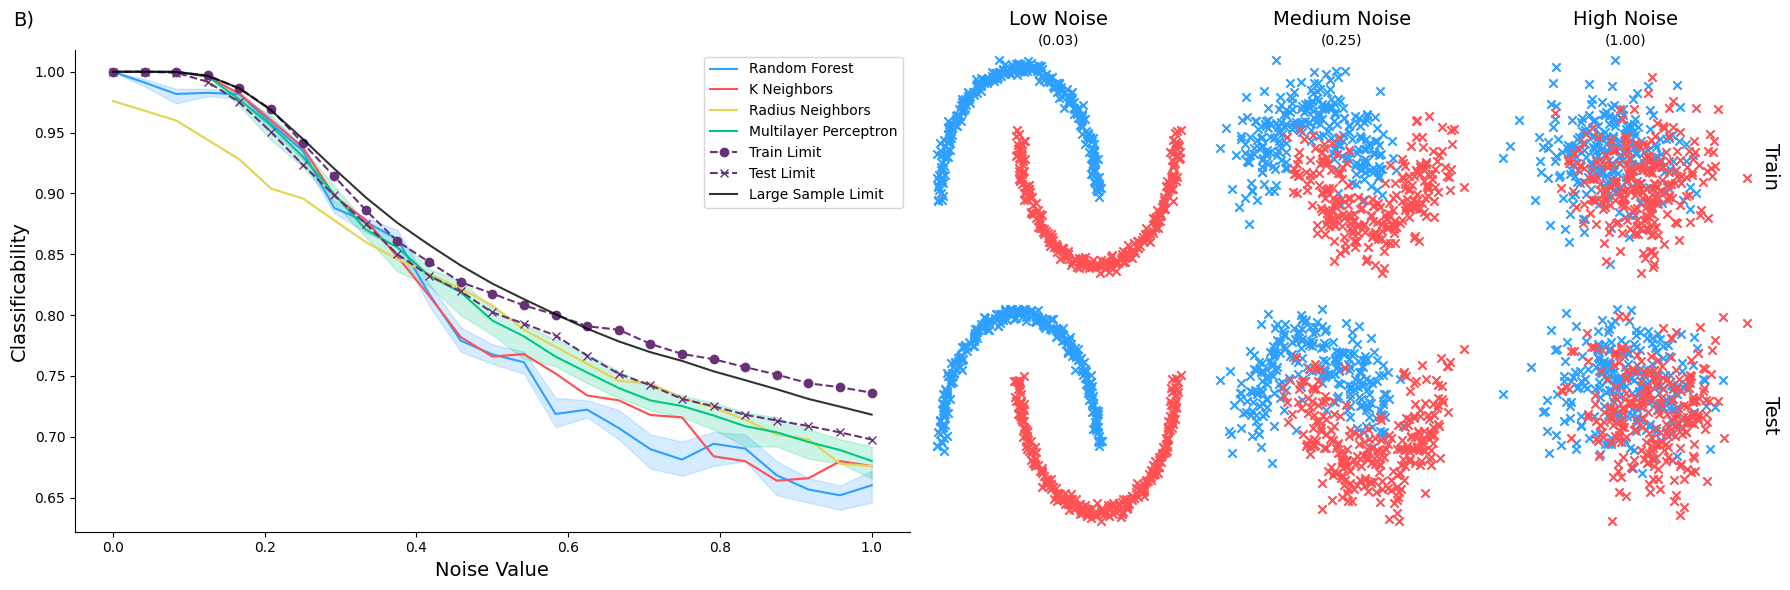

In [11]:
fig = plt.figure(figsize=(18, 6))
gs = GridSpec(2, 6, figure=fig)

ax = fig.add_subplot(gs[:, :3])

data_path = './data/two_moons'
noise_space = np.linspace(0, 1, noise_points)
dataset_fn = lambda samples, rng, noise : datasets.make_moons(n_samples=samples, noise=noise, random_state=rng)

for i, (exp, exp_long) in enumerate(zip(exp_names, exp_long_name)):
	model_errors = list(np.load(os.path.join(data_path, f'{exp}.npy')))
	ax.plot(noise_space, np.mean(model_errors, axis=1), label=exp_long, color=model_colors[i])
	ax.fill_between(noise_space, np.min(model_errors, axis=1), np.max(model_errors, axis=1), alpha=0.2, color=model_colors[i])


train_classificabilities = np.load(os.path.join(data_path, f'train_classificabilities.npy'))
test_classificabilities = np.load(os.path.join(data_path, f'test_classificabilities.npy'))
high_res_limit = np.load(os.path.join(data_path, f'high_res_limit.npy'))
ax.plot(noise_space, train_classificabilities, 'o--', alpha=1, label='Train Limit', color='#683279')
ax.plot(noise_space, test_classificabilities, 'x--', alpha=1, label='Test Limit', color='#683279')
ax.plot(noise_space, high_res_limit, 'k', alpha=0.8, label='Large Sample Limit')

ax.legend()


#ax.scatter(x_data[y_data == 0][:,0], x_data[y_data == 0][:,1])
ax.spines['top'].set_visible(False)
ax.spines['right'].set_visible(False)
ax.set_xlabel('Noise Value')
ax.set_ylabel('Classificability')

for p, rng, noise in zip(gs_pos, rng_states, noise_values):
	ax = fig.add_subplot(gs[p[0], p[1]])

	x_data, y_data = dataset_fn(n_samples, rng, noise)
	for i in range(len(np.unique(y_data))):
		ax.scatter(x_data[y_data == i][:,0], x_data[y_data == i][:,1], marker='x', color=class_colors[i])

	ax.spines['top'].set_visible(False)
	ax.spines['right'].set_visible(False)
	ax.spines['bottom'].set_visible(False)
	ax.spines['left'].set_visible(False)
	ax.set_xticks([])
	ax.set_yticks([])

fig.axes[1].set_title(f'Low Noise', fontsize=MEDIUM_SIZE)
aux_ax = fig.axes[1].twiny()
aux_ax.set_xlabel(f'({noise_values[0]:.2f})', fontsize=SMALL_SIZE)
aux_ax.spines['top'].set_visible(False)
aux_ax.spines['right'].set_visible(False)
aux_ax.spines['bottom'].set_visible(False)
aux_ax.spines['left'].set_visible(False)
aux_ax.set_xticks([])
aux_ax.set_xticklabels([])

fig.axes[2].set_title('Medium Noise', fontsize=MEDIUM_SIZE)
aux_ax = fig.axes[2].twiny()
aux_ax.set_xlabel(f'({noise_values[1]:.2f})', fontsize=SMALL_SIZE)
aux_ax.spines['top'].set_visible(False)
aux_ax.spines['right'].set_visible(False)
aux_ax.spines['bottom'].set_visible(False)
aux_ax.spines['left'].set_visible(False)
aux_ax.set_xticks([])
aux_ax.set_xticklabels([])

fig.axes[3].set_title('High Noise', fontsize=MEDIUM_SIZE)
aux_ax = fig.axes[3].twiny()
aux_ax.set_xlabel(f'({noise_values[2]:.2f})', fontsize=SMALL_SIZE)
aux_ax.spines['top'].set_visible(False)
aux_ax.spines['right'].set_visible(False)
aux_ax.spines['bottom'].set_visible(False)
aux_ax.spines['left'].set_visible(False)
aux_ax.set_xticks([])
aux_ax.set_xticklabels([])

fig.axes[3].set_ylabel('Train', rotation=270, labelpad=15)
fig.axes[3].yaxis.set_label_position("right")

fig.axes[6].set_ylabel('Test', rotation=270, labelpad=15)
fig.axes[6].yaxis.set_label_position("right")

fig.text(0.01,0.95, 'B)', fontsize=MEDIUM_SIZE)

plt.tight_layout()
plt.savefig('./images/dataset_two_moons.png', dpi=300)
plt.show()

### Example 5: Blobs

In [18]:
gs_pos = [[0,3], [0,4], [0,5], [1,3], [1,4], [1,5]]
rng_states = [42] * 3 + [43] * 3
noise_values = [0.03, 0.25, 1.0] * 2
data_path = './data/blobs'
os.makedirs(data_path, exist_ok=True)
d_value = 0.05
factor = 0.5
noise_points = 25
noise_space = np.linspace(0, 2, noise_points)
dataset_fn = lambda samples, rng, noise : datasets.make_blobs(n_samples=samples, cluster_std=noise, random_state=rng, centers=0.5*np.array([[1,1], [1,-1], [-1,1], [-1,-1]]))

train_classificabilities, test_classificabilities = [], []
for noise in noise_space:
	with np.errstate(divide='ignore', invalid='ignore'):
		# Train
		x_data, y_data = dataset_fn(n_samples, 42, noise)
		c = entropy_estimator.classificability_estimator(x_data, y_data, k_neighbors=16)
		train_classificabilities.append(c)
		# Test
		x_data, y_data = dataset_fn(n_samples, 43, noise)
		c = entropy_estimator.classificability_estimator(x_data, y_data, k_neighbors=16)
		test_classificabilities.append(c)
np.save(os.path.join(data_path, f'train_classificabilities.npy'), train_classificabilities)
np.save(os.path.join(data_path, f'test_classificabilities.npy'), test_classificabilities)

d_value = 0.015
high_res_limit = []
for noise in tqdm(noise_space):
	with np.errstate(divide='ignore', invalid='ignore'):
		# Train
		x_data, y_data = dataset_fn(25000, 42, noise)
		c = entropy_estimator.classificability_estimator(x_data, y_data, k_neighbors=32)
		high_res_limit.append(c)
np.save(os.path.join(data_path, f'high_res_limit.npy'), high_res_limit)

100%|██████████| 25/25 [00:05<00:00,  4.19it/s]


In [20]:
train_gen = lambda noise : dataset_fn(n_samples, 42, noise)
test_gen = lambda noise : dataset_fn(n_samples, 43, noise)

exp_names = ['rfc', 'knc', 'rnc', 'mlp']
exp_long_name = ['Random Forest', 'K Neighbors', 'Radius Neighbors', 'Multilayer Perceptron']
models_fn = [lambda : RandomForestClassifier(), 
			 lambda : KNeighborsClassifier(),
			 lambda : RadiusNeighborsClassifier(radius=1),
			 lambda : MLPClassifier(hidden_layer_sizes=[128,64,32], batch_size=32)]
exp_samples = [25,1,1,25]

for exp, model, s in zip(exp_names, models_fn, exp_samples):
	with warnings.catch_warnings():
		warnings.filterwarnings("ignore", category=ConvergenceWarning)
		train_models_with_noise(model, exp, train_gen, test_gen, noise_space, data_path, samples=s)

100%|██████████| 25/25 [08:06<00:00, 19.47s/it]


In [21]:
noise_values = [0.1, 0.5, 2.0] * 2

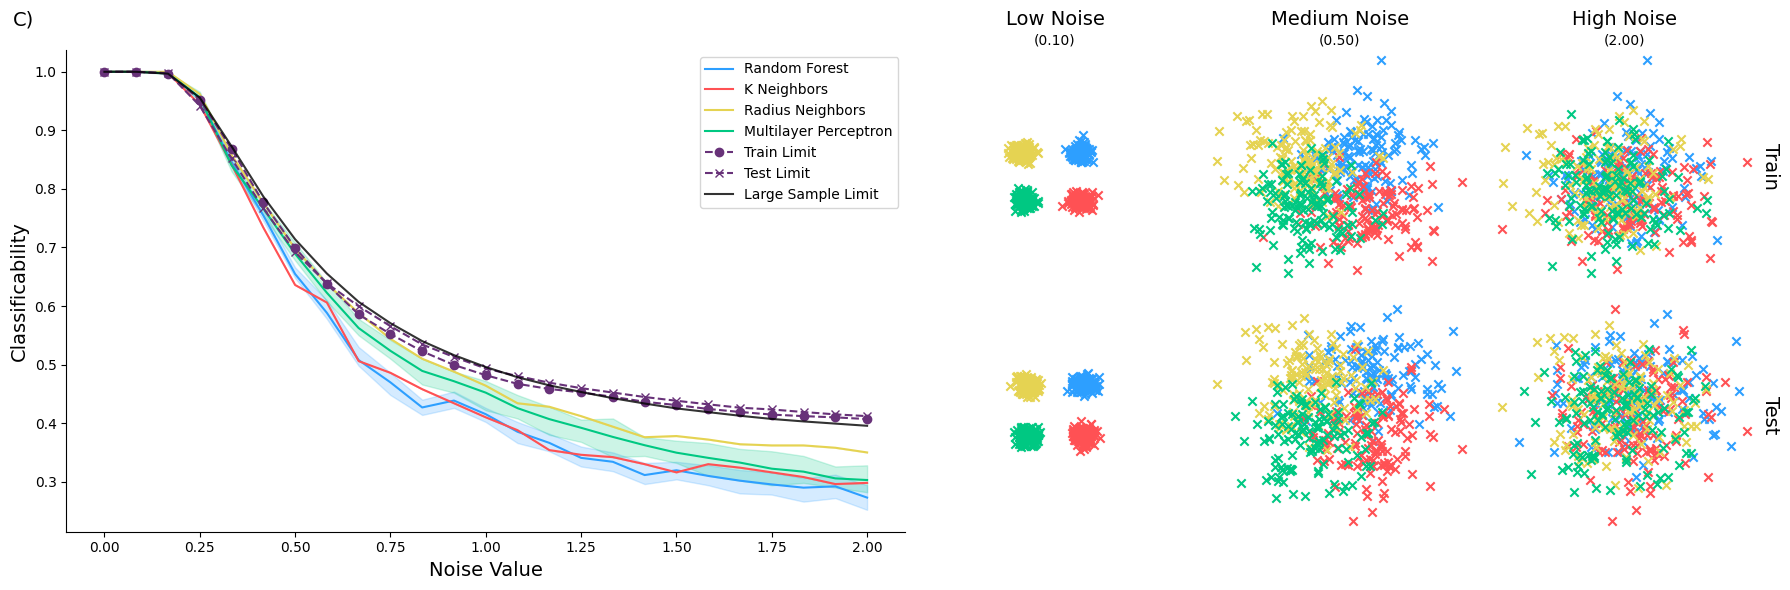

In [23]:
fig = plt.figure(figsize=(18, 6))
gs = GridSpec(2, 6, figure=fig)

ax = fig.add_subplot(gs[:, :3])

data_path = './data/blobs'
noise_space = np.linspace(0, 2, noise_points)
dataset_fn = lambda samples, rng, noise : datasets.make_blobs(n_samples=samples, cluster_std=noise, random_state=rng, centers=0.5*np.array([[1,1], [1,-1], [-1,1], [-1,-1]]))
#datasets.make_multilabel_classification(n_samples=samples, n_features=2, n_classes=4, cluster_std=noise, random_state=rng, allow_unlabeled=False)

for i, (exp, exp_long) in enumerate(zip(exp_names, exp_long_name)):
	model_errors = list(np.load(os.path.join(data_path, f'{exp}.npy')))
	ax.plot(noise_space, np.mean(model_errors, axis=1), label=exp_long, color=model_colors[i])
	ax.fill_between(noise_space, np.min(model_errors, axis=1), np.max(model_errors, axis=1), alpha=0.2, color=model_colors[i])

train_classificabilities = np.load(os.path.join(data_path, f'train_classificabilities.npy'))
test_classificabilities = np.load(os.path.join(data_path, f'test_classificabilities.npy'))
high_res_limit = np.load(os.path.join(data_path, f'high_res_limit.npy'))
ax.plot(noise_space, train_classificabilities, 'o--', alpha=1, label='Train Limit', color='#683279')
ax.plot(noise_space, test_classificabilities, 'x--', alpha=1, label='Test Limit', color='#683279')
ax.plot(noise_space, high_res_limit, 'k', alpha=0.8, label='Large Sample Limit')

ax.legend()


#ax.scatter(x_data[y_data == 0][:,0], x_data[y_data == 0][:,1])
ax.spines['top'].set_visible(False)
ax.spines['right'].set_visible(False)
ax.set_xlabel('Noise Value')
ax.set_ylabel('Classificability')

for p, rng, noise in zip(gs_pos, rng_states, noise_values):
	ax = fig.add_subplot(gs[p[0], p[1]])

	x_data, y_data = dataset_fn(n_samples, rng, noise)
	for i in range(len(np.unique(y_data))):
		ax.scatter(x_data[y_data == i][:,0], x_data[y_data == i][:,1], marker='x', color=class_colors[i])

	if p[1] == 3:
		ax.set_xlim(3*np.min(x_data[:,0]),3*np.max(x_data[:,0]))
		ax.set_ylim(3*np.min(x_data[:,1]),3*np.max(x_data[:,1]))

	ax.spines['top'].set_visible(False)
	ax.spines['right'].set_visible(False)
	ax.spines['bottom'].set_visible(False)
	ax.spines['left'].set_visible(False)
	ax.set_xticks([])
	ax.set_yticks([])

fig.axes[1].set_title(f'Low Noise', fontsize=MEDIUM_SIZE)
aux_ax = fig.axes[1].twiny()
aux_ax.set_xlabel(f'({noise_values[0]:.2f})', fontsize=SMALL_SIZE)
aux_ax.spines['top'].set_visible(False)
aux_ax.spines['right'].set_visible(False)
aux_ax.spines['bottom'].set_visible(False)
aux_ax.spines['left'].set_visible(False)
aux_ax.set_xticks([])
aux_ax.set_xticklabels([])

fig.axes[2].set_title('Medium Noise', fontsize=MEDIUM_SIZE)
aux_ax = fig.axes[2].twiny()
aux_ax.set_xlabel(f'({noise_values[1]:.2f})', fontsize=SMALL_SIZE)
aux_ax.spines['top'].set_visible(False)
aux_ax.spines['right'].set_visible(False)
aux_ax.spines['bottom'].set_visible(False)
aux_ax.spines['left'].set_visible(False)
aux_ax.set_xticks([])
aux_ax.set_xticklabels([])

fig.axes[3].set_title('High Noise', fontsize=MEDIUM_SIZE)
aux_ax = fig.axes[3].twiny()
aux_ax.set_xlabel(f'({noise_values[2]:.2f})', fontsize=SMALL_SIZE)
aux_ax.spines['top'].set_visible(False)
aux_ax.spines['right'].set_visible(False)
aux_ax.spines['bottom'].set_visible(False)
aux_ax.spines['left'].set_visible(False)
aux_ax.set_xticks([])
aux_ax.set_xticklabels([])

fig.axes[3].set_ylabel('Train', rotation=270, labelpad=15)
fig.axes[3].yaxis.set_label_position("right")

fig.axes[6].set_ylabel('Test', rotation=270, labelpad=15)
fig.axes[6].yaxis.set_label_position("right")

fig.text(0.01,0.95, 'C)', fontsize=MEDIUM_SIZE)

plt.tight_layout()
plt.savefig('./images/dataset_blobs.png', dpi=300)
plt.show()